# 03. 線形 ODE と連立系 — 行列・固有値・振動

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

高階の線形 ODE や複数の量が絡む系は、補助変数を導入すると必ず **一階の連立線形系**

$$
\frac{d\mathbf{x}}{dt} = A\mathbf{x}
$$

に書けます。ここから先は **線形代数の言葉**——行列 $A$ の **固有値** が、解が「振動するか・減衰するか・発散するか」を決めます。

## 2. Problem / 3. Intuition — 振り子とバネ

バネ・振り子・電気回路はどれも

$$
\ddot{x} + 2\gamma\,\dot{x} + \omega^2 x = F(t)
$$

の形(減衰 + 復元力 + 外力)。$x$ と速度 $v=\dot{x}$ を状態に取ると、二階方程式が一階の 2 次元系になります。

$$
\frac{d}{dt}\begin{pmatrix} x \\ v \end{pmatrix}
= \begin{pmatrix} 0 & 1 \\ -\omega^2 & -2\gamma \end{pmatrix}
\begin{pmatrix} x \\ v \end{pmatrix} + \begin{pmatrix} 0 \\ F(t) \end{pmatrix}
$$

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting, datasets

## 4. Visualization / 6. Computation — 減衰の 4 つの顔

$\omega = 1$ を固定し、減衰 $\gamma$ を変えると挙動が質的に変わります:
**無減衰(振動が続く)→ 弱減衰(振動しつつ収束)→ 臨界 → 過減衰(振動せず収束)**。

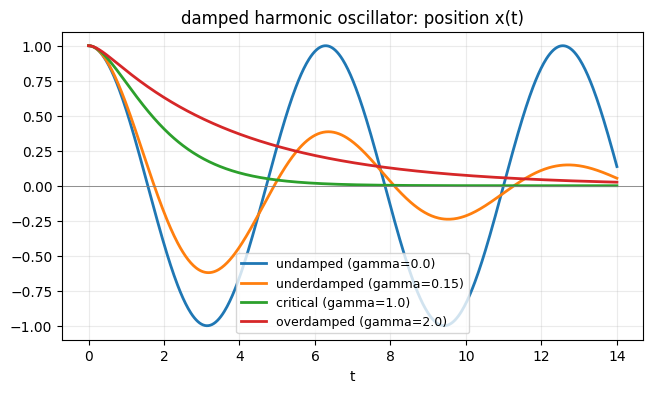

In [3]:
# Four damping regimes of x'' + 2γ x' + ω^2 x = 0.
scen = datasets.harmonic_scenarios()
fig, ax = plt.subplots(figsize=(7.5, 4))
for name, sc in scen.items():
    f = systems.harmonic_oscillator(sc.params["omega"], sc.params["gamma"])
    Y = solvers.rk4(f, sc.y0, sc.t)
    ax.plot(sc.t, Y[:, 0], lw=2, label=f"{name} (gamma={sc.params['gamma']})")
ax.axhline(0, color="gray", lw=0.6)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title("damped harmonic oscillator: position x(t)")
plt.show()

## 5. Definition — 固有値が振る舞いを決める

$d\mathbf{x}/dt = A\mathbf{x}$ の解は $A$ の固有値 $\lambda$ と固有ベクトル $\mathbf{v}$ を使って
$\mathbf{x}(t) = \sum_k c_k e^{\lambda_k t}\mathbf{v}_k$ と書けます。

- $\mathrm{Re}\,\lambda < 0$ → 減衰、$> 0$ → 発散
- $\mathrm{Im}\,\lambda \ne 0$ → 振動(角振動数 $\approx |\mathrm{Im}\,\lambda|$)

振動子の行列の固有値を、減衰ごとに見てみます。

In [4]:
import numpy as np

# Eigenvalues of the oscillator matrix explain each regime.
for name, sc in datasets.harmonic_scenarios().items():
    w, g = sc.params["omega"], sc.params["gamma"]
    A = np.array([[0.0, 1.0], [-(w**2), -2 * g]])
    eig = np.linalg.eigvals(A)
    print(f"{name:12s} gamma={g:.2f}  eigenvalues = {np.round(eig, 3)}")

undamped     gamma=0.00  eigenvalues = [ 0.+1.j -0.-1.j]
underdamped  gamma=0.15  eigenvalues = [-0.15+0.989j -0.15-0.989j]
critical     gamma=1.00  eigenvalues = [-1. -1.]
overdamped   gamma=2.00  eigenvalues = [-0.268 -3.732]


## 7. Invariant — エネルギー

無減衰($\gamma=0$)では **力学的エネルギー** $E = \tfrac12(v^2 + \omega^2 x^2)$ が保存します。
数値解でも(良いソルバなら)ほぼ一定に保たれることを確認します。

In [5]:
import numpy as np

# Energy is conserved when undamped (a good check on the integrator).
f = systems.harmonic_oscillator(omega=1.0, gamma=0.0)
t = np.linspace(0, 20, 2001)
Y = solvers.rk4(f, [1.0, 0.0], t)
E = 0.5 * (Y[:, 1] ** 2 + Y[:, 0] ** 2)
print("energy drift over t in [0,20]:", np.max(np.abs(E - E[0])))

energy drift over t in [0,20]: 1.3889778216480408e-11


## 8. Failure Mode / 9. Application — 共振

外力 $F(t) = F_0\cos(\Omega t)$ を加えると、駆動振動数 $\Omega$ が固有振動数 $\omega$ に近いとき
振幅が跳ね上がる **共振** が起きます。定常振幅は

$$
A(\Omega) = \frac{F_0}{\sqrt{(\omega^2 - \Omega^2)^2 + (2\gamma\Omega)^2}}
$$

減衰 $\gamma$ が小さいほど鋭いピーク。橋や建物の設計で避けるべき現象です。

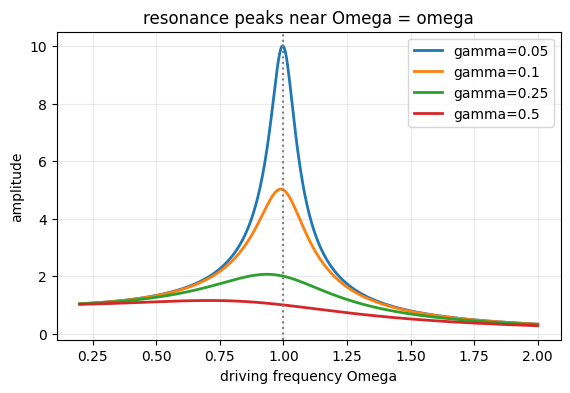

In [6]:
import numpy as np

# Resonance: steady-state amplitude vs driving frequency, several damping levels.
F0, w = 1.0, 1.0
Omega = np.linspace(0.2, 2.0, 400)
fig, ax = plt.subplots(figsize=(6.5, 4))
for g in (0.05, 0.1, 0.25, 0.5):
    A = F0 / np.sqrt((w**2 - Omega**2) ** 2 + (2 * g * Omega) ** 2)
    ax.plot(Omega, A, lw=2, label=f"gamma={g}")
ax.axvline(w, color="gray", ls=":")
ax.legend()
ax.grid(alpha=0.25)
ax.set_xlabel("driving frequency Omega")
ax.set_ylabel("amplitude")
ax.set_title("resonance peaks near Omega = omega")
plt.show()

## Exercises

1. $\ddot{x} + 5\dot{x} + 6x = 0$ を一階系に直し、固有値 $-2, -3$ から過減衰であることを示せ。
2. 無減衰振動子のエネルギー保存を、Euler 法では破れること(エネルギーが増大)を数値で示せ。
3. 共振振幅 $A(\Omega)$ を $\Omega$ で微分し、ピーク位置 $\Omega^2 = \omega^2 - 2\gamma^2$ を導け。

## Advanced Notes

- **行列指数関数**: $d\mathbf{x}/dt = A\mathbf{x}$ の解は $\mathbf{x}(t) = e^{At}\mathbf{x}_0$。$e^{At}$ は固有分解 $A=V\Lambda V^{-1}$ で $V e^{\Lambda t} V^{-1}$。
- **重複固有値**: $A$ が対角化できないとき(Jordan ブロック)、解に $t e^{\lambda t}$ の項が現れる。臨界減衰がその例。
- **シンプレクティック積分**: 保存系では RK4 でも長時間でエネルギーがわずかに漂う。シンプレクティック法(leapfrog 等)は保存量をよく保つ。